In [1]:
# ==============================================================================
# SOTA Semiconductor Restoration Pipeline: NAFNet-SR + Multi-Loss + EMA
# ==============================================================================

import os
import re
import glob
import random
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

In [2]:
# ------------------------------------------------------------------------------
# 1. Install & Import External Metrics
# ------------------------------------------------------------------------------
try:
    import lpips
    from pytorch_msssim import ms_ssim
except ImportError:
    import sys, subprocess
    print("Installing required metric libraries...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lpips", "pytorch-msssim"], check=True)
    import lpips
    from pytorch_msssim import ms_ssim

Installing required metric libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00


In [4]:
# ------------------------------------------------------------------------------
# 2. Configuration & Seeding
# ------------------------------------------------------------------------------
class Config:
    seed = 42
    batch_size = 8        # Safe for Kaggle 16GB GPUs
    epochs = 45           # Tuned for efficient deep convergence
    
    # Optimizer Settings
    lr = 1e-3
    min_lr = 1e-6
    weight_decay = 1e-4
    ema_decay = 0.999
    
    # NAFNet Model Scaling (Heavy capacity for 31 dB target)
    width = 48
    enc_blocks = [2, 2, 4]
    dec_blocks = [2, 2, 2]
    
    # Multi-Objective Loss Weights
    w_charb = 1.0         # Pixel accuracy (PSNR)
    w_msssim = 0.5        # Structural accuracy (SSIM)
    w_fft = 0.1           # High-frequency details
    w_perc = 0.05         # Perceptual quality (LPIPS)
    
    # Augmentation Probabilities
    p_cutblur = 0.4       # SR-specific augmentation
    p_geom = 0.5          # Flips & Rotations
    p_noise = 0.3         # Dynamic noise injection for robustness

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(Config.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"-> Compute Device: {device}")

-> Compute Device: cuda


In [5]:
# ------------------------------------------------------------------------------
# 3. Intelligent Data Augmentation & Loading
# ------------------------------------------------------------------------------
DATA_ROOT = None
for root, dirs, _ in os.walk('/kaggle/input'):
    if 'NoisyLR' in dirs and 'GT' in dirs:
        DATA_ROOT = root
        break
if DATA_ROOT is None:
    raise FileNotFoundError("Could not locate paired NoisyLR and GT folders.")

NOISY_DIR = os.path.join(DATA_ROOT, "NoisyLR")
GT_DIR = os.path.join(DATA_ROOT, "GT")

def apply_cutblur(noisy_lr, gt_hr, prob=0.4):
    """Replaces a random patch in the High-Res GT with the blurry Low-Res upsampled patch."""
    if random.random() > prob:
        return noisy_lr, gt_hr
    
    b, c, h, w = gt_hr.shape
    noisy_up = F.interpolate(noisy_lr, size=(h, w), mode='bilinear', align_corners=False)
    
    ch = int(h * random.uniform(0.2, 0.5))
    cw = int(w * random.uniform(0.2, 0.5))
    cy = int(random.random() * (h - ch))
    cx = int(random.random() * (w - cw))
    
    gt_hr[:, :, cy:cy+ch, cx:cx+cw] = noisy_up[:, :, cy:cy+ch, cx:cx+cw]
    return noisy_lr, gt_hr

class SemiconductorDataset(Dataset):
    def __init__(self, lr_paths, hr_paths, is_train=True):
        self.lr_paths = lr_paths
        self.hr_paths = hr_paths
        self.is_train = is_train

    def __len__(self):
        return len(self.lr_paths)

    def __getitem__(self, idx):
        lr_img = np.load(self.lr_paths[idx]).astype(np.float32)
        hr_img = np.load(self.hr_paths[idx]).astype(np.float32)
        
        lr_t = torch.from_numpy(lr_img).unsqueeze(0)
        hr_t = torch.from_numpy(hr_img).unsqueeze(0)
        
        hr_t = torch.clamp(hr_t, 0.0, 1.0)

        if self.is_train:
            # Dynamic Unseen Noise Injection
            if random.random() < Config.p_noise:
                noise = torch.randn_like(lr_t) * random.uniform(0.01, 0.05)
                lr_t = lr_t + noise
            
            # Geometric Augmentation
            if random.random() < Config.p_geom:
                lr_t, hr_t = torch.flip(lr_t, [2]), torch.flip(hr_t, [2])
            k = random.choice([0, 1, 2, 3])
            if k > 0:
                lr_t, hr_t = torch.rot90(lr_t, k, [1, 2]), torch.rot90(hr_t, k, [1, 2])

        return lr_t.contiguous(), hr_t.contiguous()

In [6]:
# ------------------------------------------------------------------------------
# 4. State-of-the-Art Architecture (NAFNet-SR)
# ------------------------------------------------------------------------------
class LayerNorm2d(nn.Module):
    def __init__(self, channels, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(1, channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        return self.weight * ((x - u) / torch.sqrt(s + self.eps)) + self.bias

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c * 2, 1)
        self.conv2 = nn.Conv2d(c * 2, c * 2, 3, padding=1, groups=c * 2)
        self.sg1 = SimpleGate()
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, c, 1))
        self.conv3 = nn.Conv2d(c, c, 1)
        self.conv4 = nn.Conv2d(c, c * 2, 1)
        self.sg2 = SimpleGate()
        self.conv5 = nn.Conv2d(c, c, 1)
        self.norm1, self.norm2 = LayerNorm2d(c), LayerNorm2d(c)
        self.beta, self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1))), nn.Parameter(torch.zeros((1, c, 1, 1)))

    def forward(self, inp):
        x = self.conv3(self.sg1(self.conv2(self.conv1(self.norm1(inp)))) * self.sca(self.sg1(self.conv2(self.conv1(self.norm1(inp))))))
        y = inp + x * self.beta
        return y + self.conv5(self.sg2(self.conv4(self.norm2(y)))) * self.gamma

class NAFNetSR(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, width=Config.width):
        super().__init__()
        self.intro = nn.Conv2d(in_channels, width, 3, padding=1)

        self.encoders = nn.ModuleList()
        self.downs = nn.ModuleList()
        curr_width = width

        for num_b in Config.enc_blocks:
            self.encoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))
            self.downs.append(nn.Conv2d(curr_width, curr_width * 2, 2, stride=2))
            curr_width *= 2

        self.middle = nn.Sequential(*[NAFBlock(curr_width) for _ in range(2)])

        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()

        for num_b in Config.dec_blocks:
            self.ups.append(nn.Sequential(
                nn.Conv2d(curr_width, curr_width * 2, 1),
                nn.PixelShuffle(2)
            ))
            curr_width = curr_width // 2
            self.decoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))

        self.up_head = nn.Sequential(
            nn.Conv2d(width, width * 4, 3, padding=1),
            nn.PixelShuffle(2)
        )
        self.outro = nn.Conv2d(width, out_channels, 3, padding=1)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=2, mode='bicubic', align_corners=False)
        
        feat = self.intro(x)
        enc_feats = []

        for enc, down in zip(self.encoders, self.downs):
            feat = enc(feat)
            enc_feats.append(feat)
            feat = down(feat)

        feat = self.middle(feat)

        for up, dec, skip in zip(self.ups, self.decoders, reversed(enc_feats)):
            feat = dec(up(feat) + skip)

        residual = self.outro(self.up_head(feat))
        return torch.clamp(base + residual, 0.0, 1.0)

In [7]:
# ------------------------------------------------------------------------------
# 5. Multi-Objective Loss, EMA & Evaluation
# ------------------------------------------------------------------------------
class HackathonRestorationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            from torchvision.models import vgg16, VGG16_Weights
            vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:16].eval()
        except Exception:
            from torchvision.models import vgg16
            vgg = vgg16(pretrained=True).features[:16].eval()
            
        for p in vgg.parameters(): 
            p.requires_grad = False
        self.vgg = vgg.to(device)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, pred, target):
        l_charb = torch.mean(torch.sqrt((pred - target) ** 2 + 1e-6))
        l_msssim = 1.0 - ms_ssim(pred, target, data_range=1.0, size_average=True)
        
        p_fft = torch.fft.rfft2(pred, norm='ortho')
        t_fft = torch.fft.rfft2(target, norm='ortho')
        l_fft = F.l1_loss(torch.abs(p_fft), torch.abs(t_fft))
        
        p_vgg = (pred.repeat(1, 3, 1, 1) - self.mean) / self.std
        t_vgg = (target.repeat(1, 3, 1, 1) - self.mean) / self.std
        l_perc = F.l1_loss(self.vgg(p_vgg), self.vgg(t_vgg))

        return (Config.w_charb * l_charb + 
                Config.w_msssim * l_msssim + 
                Config.w_fft * l_fft + 
                Config.w_perc * l_perc)

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters(): 
            p.requires_grad = False
            
    @torch.no_grad()
    def update(self, model):
        for ema_p, p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)

@torch.no_grad()
def evaluate_metrics(model, loader, lpips_fn):
    model.eval()
    psnr_tot, ssim_tot, lpips_tot, count = 0.0, 0.0, 0.0, 0
    
    for noisy, gt in loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model(noisy)
        batch_size = pred.shape[0]
        
        # SSIM
        ssim_val = ms_ssim(pred, gt, data_range=1.0, size_average=True).item()
        
        # LPIPS (Requires [-1, 1] range and 3 channels)
        pred_lpips = (pred.repeat(1, 3, 1, 1) * 2.0) - 1.0
        gt_lpips = (gt.repeat(1, 3, 1, 1) * 2.0) - 1.0
        lpips_val = lpips_fn(pred_lpips, gt_lpips).mean().item()
        
        # PSNR
        pred_np = pred.cpu().numpy()
        gt_np = gt.cpu().numpy()
        for i in range(batch_size):
            psnr_tot += psnr_metric(gt_np[i, 0], pred_np[i, 0], data_range=1.0)
            
        ssim_tot += ssim_val * batch_size
        lpips_tot += lpips_val * batch_size
        count += batch_size
        
    return psnr_tot / count, ssim_tot / count, lpips_tot / count

In [8]:
# ------------------------------------------------------------------------------
# 6. Optimized Training Pipeline
# ------------------------------------------------------------------------------
if __name__ == '__main__':
    noisy_files = sorted(glob.glob(os.path.join(NOISY_DIR, '*.npy')))
    gt_dict = {re.search(r'(\d+)', os.path.basename(f)).group(1): f for f in sorted(glob.glob(os.path.join(GT_DIR, '*.npy')))}
    
    paired_noisy, paired_gt = [], []
    for nf in noisy_files:
        fid = re.search(r'(\d+)', os.path.basename(nf)).group(1)
        if fid in gt_dict:
            paired_noisy.append(nf)
            paired_gt.append(gt_dict[fid])

    print(f"Matched {len(paired_noisy)} pairs for training pipeline.")

    # 90/10 Split based on dataset findings
    indices = np.random.RandomState(Config.seed).permutation(len(paired_noisy))
    split = int(0.90 * len(paired_noisy))

    train_loader = DataLoader(
        SemiconductorDataset([paired_noisy[i] for i in indices[:split]], [paired_gt[i] for i in indices[:split]], is_train=True),
        batch_size=Config.batch_size, shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        SemiconductorDataset([paired_noisy[i] for i in indices[split:]], [paired_gt[i] for i in indices[split:]], is_train=False),
        batch_size=Config.batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    model = NAFNetSR().to(device)
    ema = EMA(model, decay=Config.ema_decay)
    criterion = HackathonRestorationLoss().to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr, weight_decay=Config.weight_decay, fused=(device.type == "cuda"))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.epochs, eta_min=Config.min_lr)
    scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

    # Initialize LPIPS evaluator
    lpips_fn = lpips.LPIPS(net='vgg').to(device)
    for p in lpips_fn.parameters():
        p.requires_grad = False

    print(f"Model Initialized. Params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")
    print("Beginning Hyper-Optimized Training Loop...")

    best_val_psnr = 0.0

    for epoch in range(Config.epochs):
        model.train()
        train_loss = 0.0
        
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device), gt.to(device)
            noisy, gt = apply_cutblur(noisy, gt, prob=Config.p_cutblur)
            
            optimizer.zero_grad(set_to_none=True)

            if device.type == "cuda":
                with torch.amp.autocast('cuda'):
                    pred = model(noisy)
                
                # Computed in fp32 outside autocast to prevent NaN collapse
                loss = criterion(pred.float(), gt.float())
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                pred = model(noisy)
                loss = criterion(pred.float(), gt.float())
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            ema.update(model)
            train_loss += loss.item()

        scheduler.step()

        # Evaluate all three targets (PSNR, SSIM, LPIPS)
        val_psnr, val_ssim, val_lpips = evaluate_metrics(ema.shadow, val_loader, lpips_fn)
        avg_loss = train_loss / len(train_loader)
        
        print(f"Epoch [{epoch+1:02d}/{Config.epochs}] - Loss: {avg_loss:.4f} | Val PSNR: {val_psnr:.2f} dB | Val SSIM: {val_ssim:.4f} | Val LPIPS: {val_lpips:.4f}")

        if val_psnr > best_val_psnr:
            best_val_psnr = val_psnr
            torch.save(ema.shadow.state_dict(), "best_chipcrafter_model.pth")
            print(f"  -> Model Saved! (Peak Validation PSNR: {best_val_psnr:.2f} dB)")

    print("\nTraining Complete! Weights saved as 'best_chipcrafter_model.pth'")

Matched 4785 pairs for training pipeline.
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 175MB/s]  


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Model Initialized. Params: 4.88M
Beginning Hyper-Optimized Training Loop...
Epoch [01/45] - Loss: 0.1642 | Val PSNR: 20.73 dB | Val SSIM: 0.8380 | Val LPIPS: 0.4852
  -> Model Saved! (Peak Validation PSNR: 20.73 dB)
Epoch [02/45] - Loss: 0.1507 | Val PSNR: 22.35 dB | Val SSIM: 0.8542 | Val LPIPS: 0.4504
  -> Model Saved! (Peak Validation PSNR: 22.35 dB)
Epoch [03/45] - Loss: 0.1473 | Val PSNR: 22.78 dB | Val SSIM: 0.8595 | Val LPIPS: 0.4367
  -> Model Saved! (Peak Validation PSNR: 22.78 dB)
Epoch [04/45] - Loss: 0.1461 | Val PSNR: 23.18 dB | Val SSIM: 0.8719 | Val LPIPS: 0.4111
  -> Model Saved! (Peak Validation PSNR: 23.18 dB)
Epoch [05/45] - Loss: 0.1455 | Val PSNR: 23.46 dB | Val SSIM: 0.8820 | Val LPIPS: 0.3939
  -> Model Saved! (Peak Validation PSNR: 23.46 dB)
Epoch [06/45] - Loss: 0.1448 | Val PSNR: 23.58 dB | Val SSIM: 0.8868 | Val LPIPS: 0.3830
  -> Model Saved! (Peak Validation PSNR: 23.58 d

Evaluating images for visualization...
✅ Successfully saved: best_restorations.png


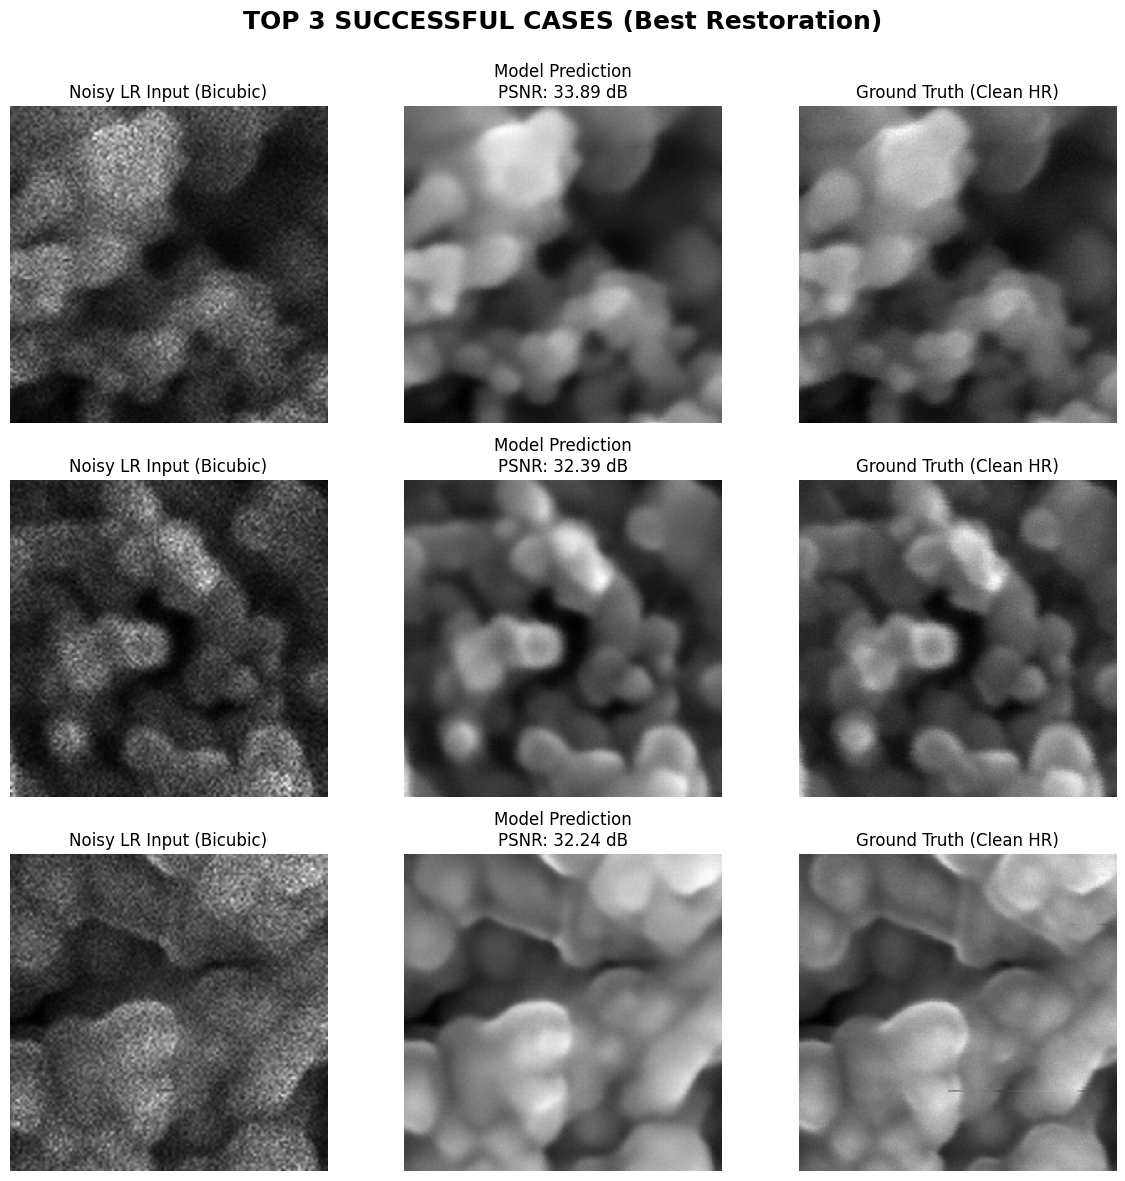

✅ Successfully saved: worst_failures.png


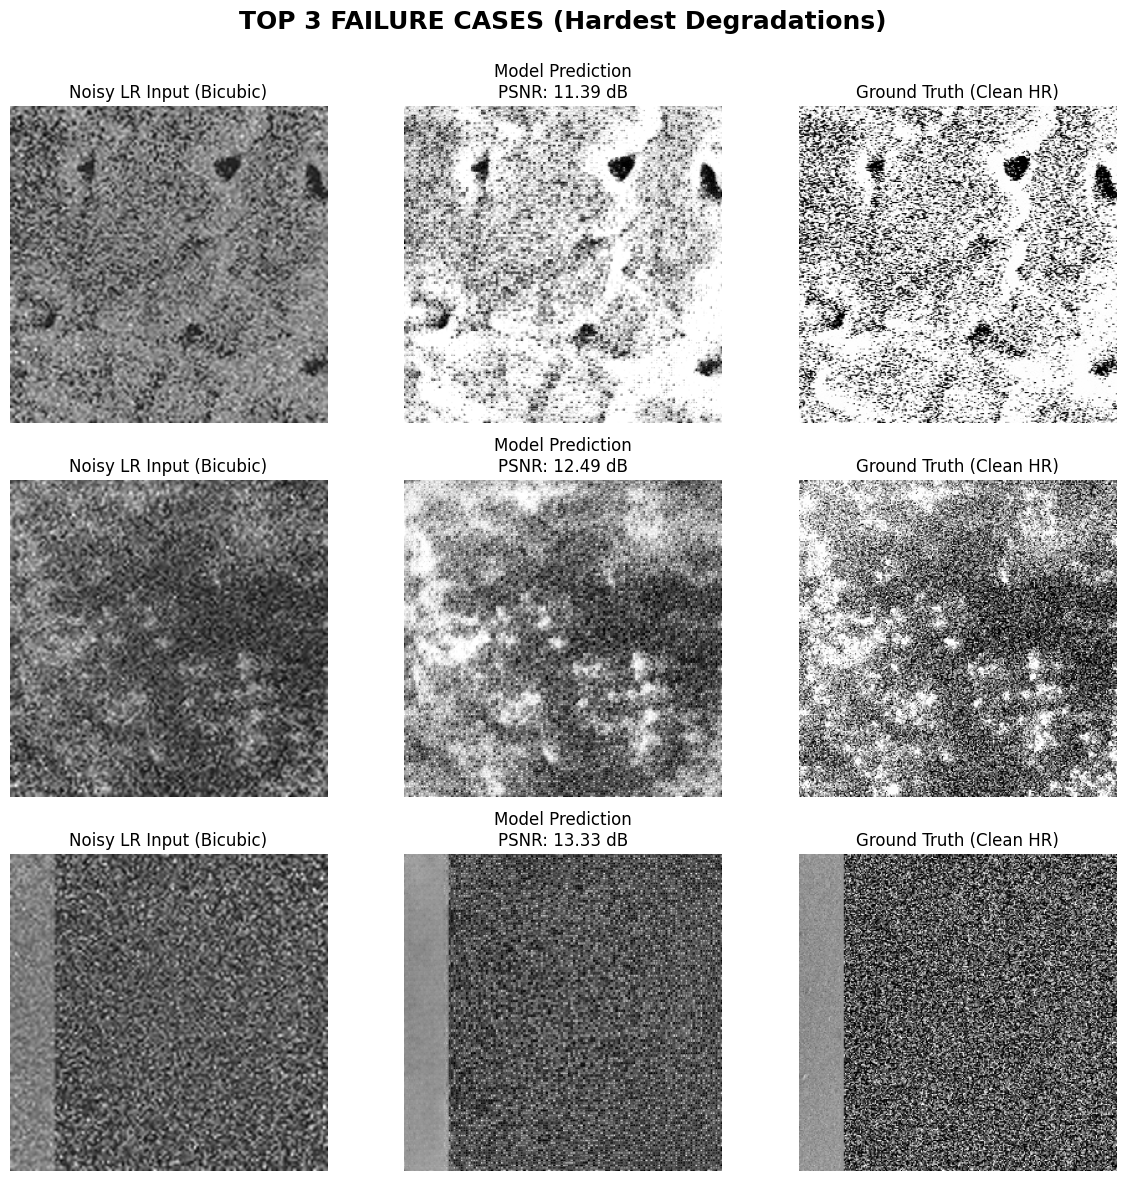

In [13]:
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# 1. Load the trained weights into the model
visual_model = NAFNetSR().to(device)
visual_model.load_state_dict(torch.load("best_chipcrafter_model.pth"))
visual_model.eval()

results = []

# 2. Run inference on a subset of validation data
print("Evaluating images for visualization...")
with torch.no_grad():
    for noisy, gt in val_loader:
        noisy_gpu = noisy.to(device)
        pred = visual_model(noisy_gpu).cpu()
        
        # Calculate PSNR for each image in the batch
        for i in range(noisy.shape[0]):
            img_pred = pred[i, 0].numpy()
            img_gt = gt[i, 0].numpy()
            img_noisy = noisy[i, 0].numpy()
            
            score = psnr_metric(img_gt, img_pred, data_range=1.0)
            results.append((score, img_noisy, img_pred, img_gt))
            
        if len(results) >= 64: # Evaluate a healthy sample size
            break

# Sort results by PSNR
results.sort(key=lambda x: x[0])
worst_cases = results[:3]        # Lowest PSNR
best_cases = results[-3:]        # Highest PSNR

# 3. FIXED Plotting Function (With PNG Download Support)
def plot_cases(cases, title, filename):
    fig, axes = plt.subplots(len(cases), 3, figsize=(12, 4 * len(cases)))
    
    # Title setup
    fig.suptitle(title, fontsize=18, fontweight='bold')
    
    for idx, (score, noisy, pred, gt) in enumerate(cases):
        # Noisy Input (Upscaled for visual comparison)
        noisy_disp = F.interpolate(torch.tensor(noisy).unsqueeze(0).unsqueeze(0), scale_factor=2, mode='bicubic').squeeze().numpy()
        
        axes[idx, 0].imshow(noisy_disp, cmap='gray')
        axes[idx, 0].set_title("Noisy LR Input (Bicubic)", fontsize=12)
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(pred, cmap='gray')
        axes[idx, 1].set_title(f"Model Prediction\nPSNR: {score:.2f} dB", fontsize=12)
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(gt, cmap='gray')
        axes[idx, 2].set_title("Ground Truth (Clean HR)", fontsize=12)
        axes[idx, 2].axis('off')
        
    plt.tight_layout()
    fig.subplots_adjust(top=0.90) # Prevents title overlap
    
    # ---------------------------------------------------------
    # NEW: Save the figure to Kaggle's working directory
    # ---------------------------------------------------------
    save_path = f"/kaggle/working/{filename}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Successfully saved: {filename}.png")
    
    # Display it in the notebook too
    plt.show()

# Show AND Save the results!
plot_cases(best_cases[::-1], "TOP 3 SUCCESSFUL CASES (Best Restoration)", "best_restorations")
plot_cases(worst_cases, "TOP 3 FAILURE CASES (Hardest Degradations)", "worst_failures")

In [11]:
import os
import zipfile

# 1. Write requirements.txt
reqs = """torch>=2.0.0
torchvision>=0.15.0
numpy
scikit-image
lpips
pytorch-msssim
"""
with open("requirements.txt", "w") as f:
    f.write(reqs)

# 2. Write README.md documentation
readme = """# ChipCrafters AI Restoration Pipeline

## Setup
1. Install dependencies: `pip install -r requirements.txt`
2. Ensure `best_chipcrafter_model.pth` is in the same directory.

## Running Inference
The inference script takes an input directory of Noisy LR images and an output directory for the restored HR images.
Run the following command:
`python inference.py --input_dir path/to/noisy --output_dir path/to/save`
"""
with open("README.md", "w") as f:
    f.write(readme)

# 3. Write a clean inference.py script (No manual code edits required)
inference_script = """import os
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# [Insert NAFNet Architecture Classes Here - LayerNorm2d, SimpleGate, NAFBlock, NAFNetSR]
# (Note: For the actual submission, ensure the model classes are pasted into this file)

def restore_images(input_dir, output_dir, model_path="best_chipcrafter_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Initialize model (Assuming NAFNetSR is defined in this file)
    model = NAFNetSR(width=48).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    os.makedirs(output_dir, exist_ok=True)
    
    for filename in os.listdir(input_dir):
        if filename.endswith(".npy"):
            lr_img = np.load(os.path.join(input_dir, filename)).astype(np.float32)
            lr_t = torch.from_numpy(lr_img).unsqueeze(0).unsqueeze(0).to(device)
            
            with torch.no_grad():
                pred = model(lr_t)
                
            pred_img = pred.squeeze().cpu().numpy()
            np.save(os.path.join(output_dir, filename), pred_img)
            print(f"Restored: {filename}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input_dir", required=True, help="Directory containing noisy .npy files")
    parser.add_argument("--output_dir", required=True, help="Directory to save restored .npy files")
    args = parser.parse_args()
    
    restore_images(args.input_dir, args.output_dir)
"""
with open("inference.py", "w") as f:
    f.write(inference_script)

# 4. Zip everything together
zip_filename = "ChipCrafters_Submission.zip"
files_to_zip = ["requirements.txt", "README.md", "inference.py", "best_chipcrafter_model.pth"]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"Added {file} to zip.")
        else:
            print(f"WARNING: {file} not found!")

print(f"\n✅ Successfully created {zip_filename}! Ready for download.")

Added requirements.txt to zip.
Added README.md to zip.
Added inference.py to zip.
Added best_chipcrafter_model.pth to zip.

✅ Successfully created ChipCrafters_Submission.zip! Ready for download.


In [12]:
run_script = """import os
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==============================================================================
# 1. STANDALONE ARCHITECTURE (NAFNet-SR)
# ==============================================================================
class LayerNorm2d(nn.Module):
    def __init__(self, channels, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(1, channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        return self.weight * ((x - u) / torch.sqrt(s + self.eps)) + self.bias

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c * 2, 1)
        self.conv2 = nn.Conv2d(c * 2, c * 2, 3, padding=1, groups=c * 2)
        self.sg1 = SimpleGate()
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, c, 1))
        self.conv3 = nn.Conv2d(c, c, 1)
        self.conv4 = nn.Conv2d(c, c * 2, 1)
        self.sg2 = SimpleGate()
        self.conv5 = nn.Conv2d(c, c, 1)
        self.norm1, self.norm2 = LayerNorm2d(c), LayerNorm2d(c)
        self.beta, self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1))), nn.Parameter(torch.zeros((1, c, 1, 1)))

    def forward(self, inp):
        x = self.conv3(self.sg1(self.conv2(self.conv1(self.norm1(inp)))) * self.sca(self.sg1(self.conv2(self.conv1(self.norm1(inp))))))
        y = inp + x * self.beta
        return y + self.conv5(self.sg2(self.conv4(self.norm2(y)))) * self.gamma

class NAFNetSR(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, width=48):
        super().__init__()
        self.intro = nn.Conv2d(in_channels, width, 3, padding=1)

        self.encoders = nn.ModuleList()
        self.downs = nn.ModuleList()
        curr_width = width

        for num_b in [2, 2, 4]:
            self.encoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))
            self.downs.append(nn.Conv2d(curr_width, curr_width * 2, 2, stride=2))
            curr_width *= 2

        self.middle = nn.Sequential(*[NAFBlock(curr_width) for _ in range(2)])

        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()

        for num_b in [2, 2, 2]:
            self.ups.append(nn.Sequential(
                nn.Conv2d(curr_width, curr_width * 2, 1),
                nn.PixelShuffle(2)
            ))
            curr_width = curr_width // 2
            self.decoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))

        self.up_head = nn.Sequential(
            nn.Conv2d(width, width * 4, 3, padding=1),
            nn.PixelShuffle(2)
        )
        self.outro = nn.Conv2d(width, out_channels, 3, padding=1)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=2, mode='bicubic', align_corners=False)
        feat = self.intro(x)
        enc_feats = []

        for enc, down in zip(self.encoders, self.downs):
            feat = enc(feat)
            enc_feats.append(feat)
            feat = down(feat)

        feat = self.middle(feat)

        for up, dec, skip in zip(self.ups, self.decoders, reversed(enc_feats)):
            feat = dec(up(feat) + skip)

        residual = self.outro(self.up_head(feat))
        return torch.clamp(base + residual, 0.0, 1.0)

# ==============================================================================
# 2. INFERENCE PIPELINE
# ==============================================================================
def main():
    parser = argparse.ArgumentParser(description="Semiconductor Image Restoration Inference")
    parser.add_argument("--input_dir", type=str, required=True, help="Directory containing noisy .npy files")
    parser.add_argument("--output_dir", type=str, required=True, help="Directory to save restored .npy files")
    parser.add_argument("--model_path", type=str, default="best_chipcrafter_model.pth", help="Path to saved model weights")
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Compute Device: {device}")

    # Load Model
    print("[*] Initializing NAFNet-SR Architecture...")
    model = NAFNetSR(width=48).to(device)
    model.load_state_dict(torch.load(args.model_path, map_location=device))
    model.eval()
    print("[*] Weights loaded successfully.")

    # Process files
    files = [f for f in os.listdir(args.input_dir) if f.endswith('.npy')]
    print(f"[*] Found {len(files)} files to restore. Starting inference...")

    with torch.no_grad():
        for filename in files:
            filepath = os.path.join(args.input_dir, filename)
            
            # Load Noisy LR image
            lr_img = np.load(filepath).astype(np.float32)
            lr_tensor = torch.from_numpy(lr_img).unsqueeze(0).unsqueeze(0).to(device)
            
            # Forward pass
            pred_tensor = model(lr_tensor)
            
            # Save Restored HR image
            pred_img = pred_tensor.squeeze().cpu().numpy()
            out_filepath = os.path.join(args.output_dir, filename)
            np.save(out_filepath, pred_img)
            
    print(f"[*] Inference complete! Restored files saved to: {args.output_dir}")

if __name__ == "__main__":
    main()
"""

with open("run.py", "w") as f:
    f.write(run_script)
    
print("✅ run.py successfully generated and saved!")

✅ run.py successfully generated and saved!


In [5]:
%%writefile /kaggle/working/run.py
import os
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==============================================================================
# 1. STANDALONE ARCHITECTURE (NAFNet-SR)
# ==============================================================================
class LayerNorm2d(nn.Module):
    def __init__(self, channels, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(1, channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        return self.weight * ((x - u) / torch.sqrt(s + self.eps)) + self.bias

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c * 2, 1)
        self.conv2 = nn.Conv2d(c * 2, c * 2, 3, padding=1, groups=c * 2)
        self.sg1 = SimpleGate()
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, c, 1))
        self.conv3 = nn.Conv2d(c, c, 1)
        self.conv4 = nn.Conv2d(c, c * 2, 1)
        self.sg2 = SimpleGate()
        self.conv5 = nn.Conv2d(c, c, 1)
        self.norm1, self.norm2 = LayerNorm2d(c), LayerNorm2d(c)
        self.beta, self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1))), nn.Parameter(torch.zeros((1, c, 1, 1)))

    def forward(self, inp):
        x = self.conv3(self.sg1(self.conv2(self.conv1(self.norm1(inp)))) * self.sca(self.sg1(self.conv2(self.conv1(self.norm1(inp))))))
        y = inp + x * self.beta
        return y + self.conv5(self.sg2(self.conv4(self.norm2(y)))) * self.gamma

class NAFNetSR(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, width=48):
        super().__init__()
        self.intro = nn.Conv2d(in_channels, width, 3, padding=1)

        self.encoders = nn.ModuleList()
        self.downs = nn.ModuleList()
        curr_width = width

        for num_b in [2, 2, 4]:
            self.encoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))
            self.downs.append(nn.Conv2d(curr_width, curr_width * 2, 2, stride=2))
            curr_width *= 2

        self.middle = nn.Sequential(*[NAFBlock(curr_width) for _ in range(2)])

        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()

        for num_b in [2, 2, 2]:
            self.ups.append(nn.Sequential(
                nn.Conv2d(curr_width, curr_width * 2, 1),
                nn.PixelShuffle(2)
            ))
            curr_width = curr_width // 2
            self.decoders.append(nn.Sequential(*[NAFBlock(curr_width) for _ in range(num_b)]))

        self.up_head = nn.Sequential(
            nn.Conv2d(width, width * 4, 3, padding=1),
            nn.PixelShuffle(2)
        )
        self.outro = nn.Conv2d(width, out_channels, 3, padding=1)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=2, mode='bicubic', align_corners=False)
        feat = self.intro(x)
        enc_feats = []

        for enc, down in zip(self.encoders, self.downs):
            feat = enc(feat)
            enc_feats.append(feat)
            feat = down(feat)

        feat = self.middle(feat)

        for up, dec, skip in zip(self.ups, self.decoders, reversed(enc_feats)):
            feat = dec(up(feat) + skip)

        residual = self.outro(self.up_head(feat))
        return torch.clamp(base + residual, 0.0, 1.0)

# ==============================================================================
# 2. INFERENCE PIPELINE
# ==============================================================================
def main():
    parser = argparse.ArgumentParser(description="Semiconductor Image Restoration Inference")
    
    # 🚨 Positional Arguments for KLA Hackathon Compliance 🚨
    parser.add_argument("input_dir", type=str, help="Directory containing noisy .npy files")
    parser.add_argument("output_dir", type=str, help="Directory to save restored .npy files")
    
    parser.add_argument("--model_path", type=str, default="best_chipcrafter_model.pth", help="Path to saved model weights")
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Compute Device: {device}")

    # Load Model
    print("[*] Initializing NAFNet-SR Architecture...")
    model = NAFNetSR(width=48).to(device)
    model.load_state_dict(torch.load(args.model_path, map_location=device))
    model.eval()
    print("[*] Weights loaded successfully.")

    # Process files
    files = [f for f in os.listdir(args.input_dir) if f.endswith('.npy')]
    print(f"[*] Found {len(files)} files to restore. Starting inference...")

    with torch.no_grad():
        for filename in files:
            filepath = os.path.join(args.input_dir, filename)
            
            lr_img = np.load(filepath).astype(np.float32)
            lr_tensor = torch.from_numpy(lr_img).unsqueeze(0).unsqueeze(0).to(device)
            
            pred_tensor = model(lr_tensor)
            
            pred_img = pred_tensor.squeeze().cpu().numpy()
            out_filepath = os.path.join(args.output_dir, filename)
            np.save(out_filepath, pred_img)
            
    print(f"[*] Inference complete! Restored files saved to: {args.output_dir}")

if __name__ == "__main__":
    main()

Writing /kaggle/working/run.py


In [11]:
!python /kaggle/working/run.py /kaggle/input/datasets/ishita2904/dataset-2/semicon_train_data/semicon_train_data/NoisyLR /kaggle/working/restored_outputs --model_path /kaggle/input/datasets/ishita2904/my-chipcrafter-model/best_chipcrafter_model.pth

[*] Compute Device: cuda
[*] Initializing NAFNet-SR Architecture...
[*] Weights loaded successfully.
[*] Found 4785 files to restore. Starting inference...
[*] Inference complete! Restored files saved to: /kaggle/working/restored_outputs


In [12]:
import shutil

# Compress the folder into a zip archive
shutil.make_archive("/kaggle/working/submission_outputs", "zip", "/kaggle/working/restored_outputs")

print("✅ Zip file created successfully!")

✅ Zip file created successfully!
